# Lineare Regression: Einkommen vorhersagen (`ConvertedTotalComp`)



In [18]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:

df = pd.read_csv("../One-Hot-Encoded.csv")


q98 = df["ConvertedCompTotal"].dropna().quantile(0.98)
df = df[df["ConvertedCompTotal"] <= q98].copy()
print(df["ConvertedCompTotal"].describe())

df = df[df["ConvertedCompTotal"] > 10000].copy()

bool_cols = df.select_dtypes(include=['bool']).columns

for col in bool_cols:
    df[col] = df[col].astype(int)
df.dtypes

count     21785.000000
mean      86982.492836
std       63772.008524
min           0.000000
25%       40873.000000
50%       75924.190383
75%      120000.000000
max      331000.000000
Name: ConvertedCompTotal, dtype: float64


MaxAge                                                            float64
AgeNum                                                            float64
WorkExp                                                           float64
YearsCode                                                         float64
RemoteCategoryNum                                                 float64
                                                                   ...   
AIAgents_no, i use ai exclusively in copilot/autocomplete mode      int64
AIAgents_yes, i use ai agents at work daily                         int64
AIAgents_yes, i use ai agents at work monthly or infrequently       int64
AIAgents_yes, i use ai agents at work weekly                        int64
AIAgents_nan                                                        int64
Length: 484, dtype: object

In [3]:
TARGET = "ConvertedCompTotal"

num_cols = df.select_dtypes(include=["number"]).columns.tolist()
feature_cols = [c for c in num_cols if c != TARGET]

X = df[feature_cols].copy()
y = df[TARGET].copy()
X = X.drop(columns=["ConvertedCompYearly"])


# Konsistentes Dropna (X vollständig + y vorhanden)
mask = X.notna().all(axis=1) & y.notna()
X = X.loc[mask].copy()
y = y.loc[mask].copy()

print("After dropna -> X:", X.shape, "y:", y.shape)
y.describe()

After dropna -> X: (14415, 467) y: (14415,)


count     14415.000000
mean      97978.747468
std       59526.405376
min       10000.000000
25%       54983.898799
50%       85249.400000
75%      128927.870461
max      331000.000000
Name: ConvertedCompTotal, dtype: float64

In [4]:
y_model = y.astype(float)
y_model.head()

0     61659.84
1    105102.00
3     36435.36
7     72000.00
8     70000.00
Name: ConvertedCompTotal, dtype: float64

In [5]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_model,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (11532, 467) Test: (2883, 467)


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

num_cols = ["MaxAge", "AgeNum", "WorkExp", "YearsCode", "RemoteCategoryNum"]
dummy_cols = [c for c in X.columns if c not in num_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("dum", "passthrough", dummy_cols),
    ],
    remainder="drop"
)


In [7]:

scaler = StandardScaler()
X_train_sc = preprocess.fit_transform(X_train)
X_test_sc  = preprocess.transform(X_test)



In [8]:
clf = LinearRegression()
clf.fit(X_train_sc, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
predicted = clf.predict(X_test_sc)
expected = y_test


test_predict_mean = np.full(len(y_test), y_train.mean())
print("Baseline Mean RMSE:")
rmse_baseline = np.sqrt(mean_squared_error(expected, test_predict_mean))
print(rmse_baseline)

print ("RMSE:")
rmse = np.sqrt(mean_squared_error(expected, predicted))
print (rmse)
print("R^2:")
r2 = r2_score(expected, predicted)
print (r2)
print("MAE:")
mae = mean_absolute_error(expected, predicted)
print (mae)

Baseline Mean RMSE:
59177.48191537781
RMSE:
37883.097760498495
R^2:
0.5898964029747615
MAE:
26984.678891206022


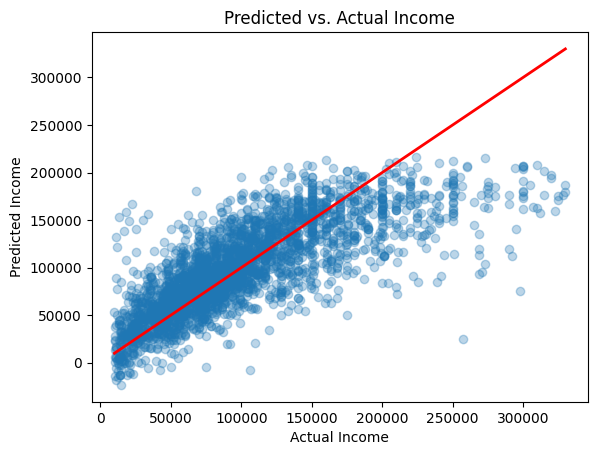

In [10]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(expected, predicted, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=2
)
plt.xlabel("Actual Income")
plt.ylabel("Predicted Income")
plt.title("Predicted vs. Actual Income")
plt.show()



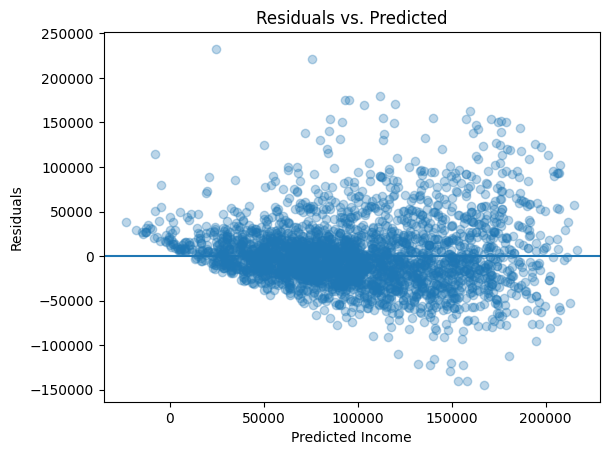

In [11]:
residuals = expected - predicted

plt.figure()
plt.scatter(predicted, residuals, alpha=0.3)
plt.axhline(0)
plt.xlabel("Predicted Income")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted")
plt.show()


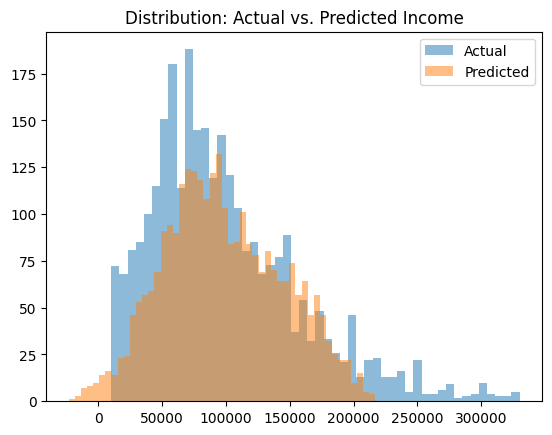

In [12]:
plt.figure()
plt.hist(expected, bins=50, alpha=0.5, label="Actual")
plt.hist(predicted, bins=50, alpha=0.5, label="Predicted")
plt.legend()
plt.title("Distribution: Actual vs. Predicted Income")
plt.show()


In [13]:
print("Intercept:", clf.intercept_)


coeff_df = pd.DataFrame({"Feature": X.columns, "Coefficient": clf.coef_})
print("\nFeature Coefficients:\n", coeff_df)

Intercept: 28249.451724648767

Feature Coefficients:
                                                Feature   Coefficient
0                                               MaxAge  -1837.471895
1                                               AgeNum  -4365.651052
2                                              WorkExp  13071.782825
3                                            YearsCode   6626.310156
4                                    RemoteCategoryNum  -3155.275528
..                                                 ...           ...
462  AIAgents_no, i use ai exclusively in copilot/a...  -1847.223949
463        AIAgents_yes, i use ai agents at work daily   2123.916560
464  AIAgents_yes, i use ai agents at work monthly ...   2221.360394
465       AIAgents_yes, i use ai agents at work weekly   3012.220312
466                                       AIAgents_nan  -2865.259636

[467 rows x 2 columns]


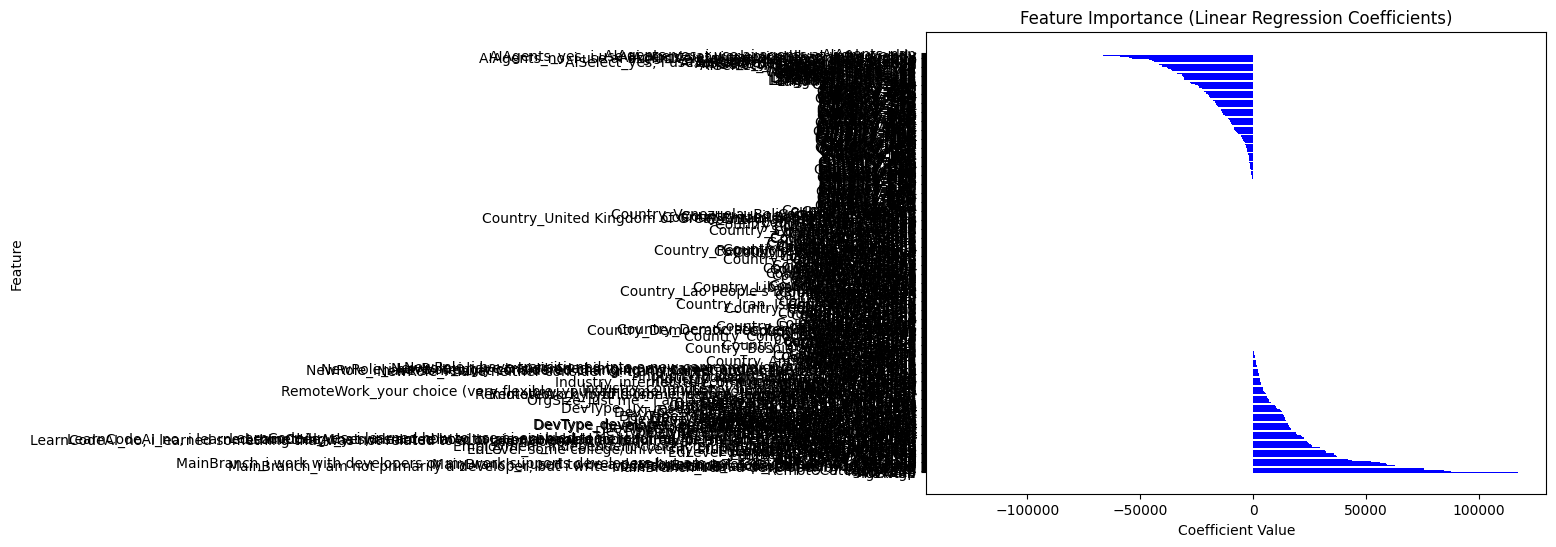

In [24]:
# Sort dataframe by coefficients.
coef_df_sorted = coeff_df.sort_values(by="Coefficient", ascending=False)


# Create plot.
plt.figure(figsize=(8,6))
plt.barh(coeff_df["Feature"], coef_df_sorted["Coefficient"], color="blue")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Feature Importance (Linear Regression Coefficients)")
plt.show()

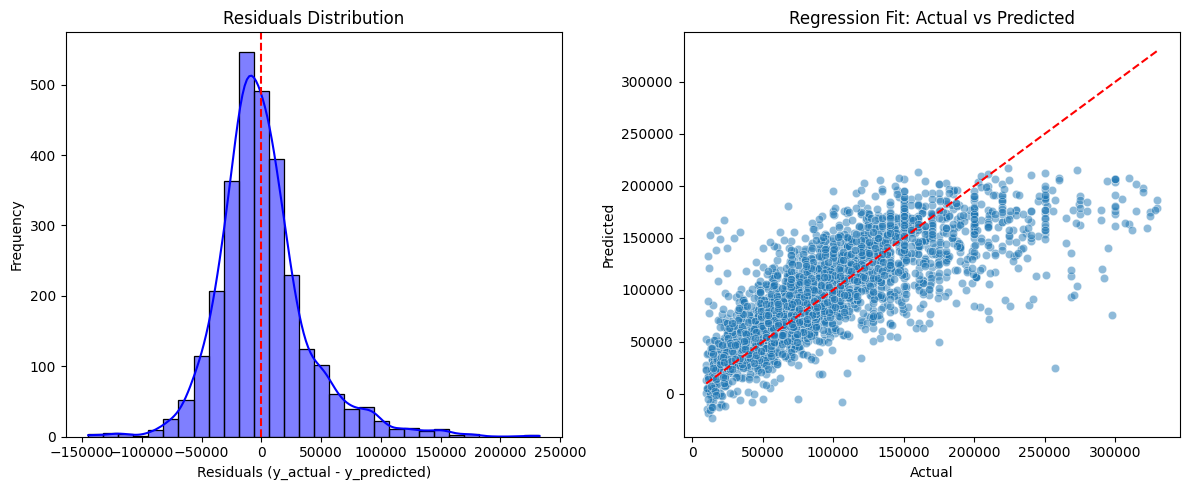

In [21]:
# Compute residuals.
residuals = expected - predicted

# Create plots.
plt.figure(figsize=(12,5))


# Plot 1: Residuals Distribution.
plt.subplot(1,2,1)
sns.histplot(residuals, bins=30, kde=True, color="blue")
plt.axvline(x=0, color='red', linestyle='--')
plt.title("Residuals Distribution")
plt.xlabel("Residuals (y_actual - y_predicted)")
plt.ylabel("Frequency")


# Plot 2: Regression Fit (Actual vs Predicted).
plt.subplot(1,2,2)
sns.scatterplot(x=expected, y=predicted, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')  # Perfect fit line
plt.title("Regression Fit: Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")


# Show plots.
plt.tight_layout()
plt.show()